# Block 4 — Hyperparameter Tuning with Optuna

**Goals for this block:**

- Learn automated hyperparameter optimization with **Optuna**
- Tune a **Temporal Convolutional Network (TCN)** model
- Find optimal parameters for **TCN** with **future covariates**: calendar features (hour, day-of-week, month)
- Compare performance improvements through systematic tuning

## 0. Environment & Imports

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
tf.config.set_logical_device_configuration(gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=6500)])

import torch
#assert torch.cuda.is_available()
#torch.cuda.set_per_process_memory_fraction(0.3)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.utils.missing_values import fill_missing_values


## 1. Preprocessing function

We'll reuse our preprocessing function from previous blocks to maintain consistency across our experiments.

In [ ]:
def preprocessing_data_with_DARTS(df,
                      resample_freq='', agg_method='mean',
                      missing_strategy='linear', 
                      scaling_method='standard',
                      train_ratio=0.7, val_ratio=0.15):
    """
    Complete time series preprocessing pipeline using Darts library.
        
    Returns: train, train_y, val, val_y, test, test_y, scaler
    """
    
    # Create Darts TimeSeries
    series = TimeSeries.from_dataframe(df)

    # 1. Handle missing values
    filled_series = fill_missing_values(series, method=missing_strategy)

    # 2. Resample data
    resampled_series = filled_series.resample(resample_freq, method=agg_method)
    
    # 3. Time-aware split
    
    # Calculate split points
    total_len = len(resampled_series)
    train_end = int(total_len * train_ratio)
    val_end = int(total_len * (train_ratio + val_ratio))
    
    # Split the series
    train_series = resampled_series[:train_end]
    val_series = resampled_series[train_end:val_end]
    test_series = resampled_series[val_end:]

    # 4. Scaling (fit only on training data)
    if scaling_method == 'standard':
        scaler = StandardScaler()
    elif scaling_method == 'minmax':
        scaler = MinMaxScaler()
    elif scaling_method == 'robust':
        scaler = RobustScaler()
    elif scaling_method == 'maxabs':
        scaler = MaxAbsScaler()
    else:
        raise ValueError(f"Unsupported scaling method: {scaling_method}")
        
    scaler = Scaler(scaler)
    
    # Fit on training data and transform all sets
    scaler.fit(train_series)
    train_scaled = scaler.transform(train_series)
    val_scaled = scaler.transform(val_series)
    test_scaled = scaler.transform(test_series)
    
    # 5. WINDOWING
    ######## NOT NEEDED WITH DARTS MODELS ##########

    return train_scaled, val_scaled, test_scaled, scaler

## 2. Load & Prepare Data

Load the electricity consumption dataset and prepare it for time series forecasting.

In [ ]:
#from darts.datasets import ElectricityConsumptionZurichDataset

# series = ElectricityConsumptionZurichDataset().load() 
# target_columns = ["Value_NE5", "Value_NE7"]
# covariate_columns = ['Hr [%Hr]', 'RainDur [min]', 'StrGlo [W/m2]', 'T [°C]', 'WD [°]', 'WVs [m/s]', 'WVv [m/s]', 'p [hPa]']

# # splt the time series into target and covariates
# target_series = series[target_columns]
# past_covariates = series[covariate_columns]

df = pd.read_csv("electricity.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df['timestamp'] = df['timestamp'].dt.tz_localize(None)
df = df.set_index('timestamp').sort_index()


<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Prepare data for training</h2>

1. Preprocess the dataset using our preprocessing pipeline

2. Add relevant future covariates - consider what temporal features might be important:
    - Do we need hourly attributes for capturing daily patterns?
    - Do we need daily attributes for weekly seasonality?
    - Do we need monthly attributes for seasonal trends?  

This step is crucial for improving model performance by providing additional context.


</div>

#### 2.1 Basic Preprocessing

Apply our standard preprocessing pipeline to the electricity data.

In [ ]:
train_target, val_target, test_target, scaler_target = preprocessing_data_with_DARTS(df,
                                              resample_freq='h', agg_method='sum',
                                              missing_strategy='linear', 
                                              scaling_method='standard',
                                              train_ratio=0.7, val_ratio=0.15)  

### 2.2 Adding Future Covariates

Create calendar-based features that can help the model understand temporal patterns.

In [ ]:
# adding future covariates to the data using datetime_attribute_timeseries

from darts.utils.timeseries_generation import datetime_attribute_timeseries


preprocessed_series = train_target.append(val_target).append(test_target)

hour_series  = datetime_attribute_timeseries(preprocessed_series, attribute="hour", one_hot=False, cyclic=True)
dow_series   = datetime_attribute_timeseries(preprocessed_series, attribute="day_of_week", one_hot=True)
month_series = datetime_attribute_timeseries(preprocessed_series, attribute="month", one_hot=True)

future_covs  = hour_series.stack(dow_series).stack(month_series)

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Hyperparameter Optimization with Optuna</h2>

Learn how to systematically find the best model configuration using Optuna's optimization framework.

1. Build the objective function that defines what to optimize

2. Run a tuning job to find optimal hyperparameters

This exercise will teach you automated hyperparameter optimization for time series models.

</div>

### 1. **Study**: The optimization session
```python
study = optuna.create_study(direction="minimize", study_name="LSTM_sMAPE")
```
- `direction`: "minimize" (for loss/error) or "maximize" (for accuracy)
- `study_name`: Identifier for tracking experiments

#### 2. **Trial**: Single hyperparameter configuration attempt
```python
def objective_lstm(trial):
    # Suggest hyperparameter values
    window_size = 24 * trial.suggest_int("window_size_factor", 1, 7)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 96, 128])
    
    # Train model with suggested parameters
    model = RNNModel(input_chunk_length=window_size, hidden_dim=hidden_dim, ...)
    
    # Return metric to optimize
    return validation_error
```

#### 3. **Hyperparameter Suggestion Methods**

| Method | Use Case | Example |
|--------|----------|---------|
| `suggest_int(name, low, high)` | Integer ranges | `trial.suggest_int("layers", 1, 5)` |
| `suggest_float(name, low, high)` | Continuous values | `trial.suggest_float("lr", 1e-5, 1e-1, log=True)` |
| `suggest_categorical(name, choices)` | Discrete choices | `trial.suggest_categorical("optimizer", ["adam", "sgd"])` |
| `suggest_uniform(name, low, high)` | Uniform distribution | `trial.suggest_uniform("dropout", 0.1, 0.5)` |


### 3.2 TCN Objective Function
Define the objective function for optimizing our Temporal Convolutional Network.

In [ ]:
# Fixed forecast horizon for all experiments
forecast_horizon = 24

Suggestion: TCN Hyperparameters to be tuned:

- `input_chunk_length`: How many past timesteps to use (2-7 days)
- `num_filters`: Number of convolutional filters (8, 16, or 32)
- `kernel_size`: Size of convolutional kernels (3 to 11)
- `dilation_base`: Base for exponential dilation (2 to 4)

In [ ]:
from darts.models import TCNModel
from darts.metrics import mae

# 1. Build the objective function
def objective_tcn(trial):
    model = TCNModel(
                input_chunk_length=24 * trial.suggest_int("input_length_factor", 2, 7),
                output_chunk_length=forecast_horizon,
                num_filters=trial.suggest_categorical("num_filters", [8, 16, 32]),
                kernel_size=trial.suggest_int("kernel_size", 3, 11, step=2),
                dilation_base=trial.suggest_int("dilation_base", 2, 4),
                dropout=0.3,
                batch_size=256,
                n_epochs=5,
                pl_trainer_kwargs={"accelerator": "cpu"},
                random_state=42
            )

    # Train the model without using validation covariates
    model.fit(
        series=train_target, 
        epochs=10,
        verbose=False)
    
    # Generate historical forecasts on validation set
    pred_series = model.historical_forecasts(series=val_target,
                                              forecast_horizon=forecast_horizon, 
                                              retrain=False, 
                                              last_points_only=True)
    
    # Inverse transform predictions and targets
    pred_unscaled = scaler_target.inverse_transform(pred_series)
    val_unscaled = scaler_target.inverse_transform(val_target)

    # Calculate and return MAE
    mae_score = mae(pred_unscaled, val_unscaled)
    return mae_score

## 4. Running Optimization Studies

Execute the hyperparameter optimization and analyze results.

### 4.1 Optimize TCN Parameters

In [ ]:
import optuna

study_tcn = optuna.create_study(direction="minimize", study_name="TCN_sMAPE")
study_tcn.optimize(objective_tcn, n_trials=15, show_progress_bar=True)
print("Best TCN MAE:", round(study_tcn.best_value, 4))
print(study_tcn.best_trial.params)


[I 2025-11-09 23:21:26,615] A new study created in memory with name: TCN_sMAPE
  0%|          | 0/15 [00:00<?, ?it/s]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 0. Best value: 70.4723:   7%|▋         | 1/15 [00:24<05:39, 24.24s/it]GPU available: True (mps), used: False
TPU available: False, u

[I 2025-11-09 23:21:50,861] Trial 0 finished with value: 70.47225483817674 and parameters: {'input_length_factor': 3, 'num_filters': 32, 'kernel_size': 7, 'dilation_base': 3}. Best is trial 0 with value: 70.47225483817674.


`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 0. Best value: 70.4723:  13%|█▎        | 2/15 [00:36<03:46, 17.39s/it]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[I 2025-11-09 23:22:03,454] Trial 1 finished with value: 84.57278724920472 and parameters: {'input_length_factor': 2, 'num_filters': 16, 'kernel_size': 3, 'dilation_base': 4}. Best is trial 0 with value: 70.47225483817674.


`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 0. Best value: 70.4723:  20%|██        | 3/15 [00:47<02:50, 14.21s/it]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


...

[I 2025-11-09 23:27:50,689] Trial 12 finished with value: 70.72168553083806 and parameters: {'input_length_factor': 7, 'num_filters': 32, 'kernel_size': 11, 'dilation_base': 4}. Best is trial 10 with value: 67.36155498616527.


`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 10. Best value: 67.3616:  93%|█████████▎| 14/15 [07:06<00:39, 39.32s/it]GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


[I 2025-11-09 23:28:33,440] Trial 13 finished with value: 68.63958194065168 and parameters: {'input_length_factor': 6, 'num_filters': 32, 'kernel_size': 11, 'dilation_base': 3}. Best is trial 10 with value: 67.36155498616527.


`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Best trial: 10. Best value: 67.3616: 100%|██████████| 15/15 [07:45<00:00, 31.02s/it]

[I 2025-11-09 23:29:11,843] Trial 14 finished with value: 69.53168473020428 and parameters: {'input_length_factor': 5, 'num_filters': 32, 'kernel_size': 11, 'dilation_base': 4}. Best is trial 10 with value: 67.36155498616527.
Best TCN MAE: 67.3616
{'input_length_factor': 6, 'num_filters': 32, 'kernel_size': 11, 'dilation_base': 4}


### 4.2 Analyze Optimization Results
Review all trials to understand hyperparameter impact on performance.

In [ ]:
df_results = study_tcn.trials_dataframe().sort_values("value")
df_results.head(15)

,number,value,datetime_start,datetime_complete,duration,params_dilation_base,params_input_length_factor,params_kernel_size,params_num_filters,state
10,10,67.361555,2025-11-09 23:25:36.092549,2025-11-09 23:26:18.965207,0 days 00:00:42.872658,4,6,11,32,COMPLETE
3,3,67.678278,2025-11-09 23:22:13.886875,2025-11-09 23:23:02.275233,0 days 00:00:48.388358,4,7,11,32,COMPLETE
11,11,67.950956,2025-11-09 23:26:18.966597,2025-11-09 23:27:02.044280,0 days 00:00:43.077683,4,6,11,32,COMPLETE
8,8,68.617182,2025-11-09 23:24:50.449405,2025-11-09 23:25:16.573038,0 days 00:00:26.123633,3,3,9,32,COMPLETE
13,13,68.639582,2025-11-09 23:27:50.690680,2025-11-09 23:28:33.440834,0 days 00:00:42.750154,3,6,11,32,COMPLETE
14,14,69.531685,2025-11-09 23:28:33.442296,2025-11-09 23:29:11.843089,0 days 00:00:38.400793,4,5,11,32,COMPLETE
0,0,70.472255,2025-11-09 23:21:26.618476,2025-11-09 23:21:50.861723,0 days 00:00:24.243247,3,3,7,32,COMPLETE
12,12,70.721686,2025-11-09 23:27:02.045649,2025-11-09 23:27:50.689170,0 days 00:00:48.643521,4,7,11,32,COMPLETE
4,4,71.056975,2025-11-09 23:23:02.276751,2025-11-09 23:23:57.255336,0 days 00:00:54.978585,2,7,5,32,COMPLETE
2,2,76.497534,2025-11-09 23:22:03.456221,2025-11-09 23:22:13.885392,0 days 00:00:10.429171,2,2,9,16,COMPLETE


This table shows:

- value: Validation MAE (lower is better)

- params_*: Hyperparameter values for each trial

- Results sorted by performance (best first)

## 5. Final Evaluation on Test

Let's evaluate our best model and compare its performance with the RNN model from BLOCK 2

### 5.1 Train Best Model on Full Training Data


In [ ]:
from darts.metrics import mae

# Rebuild the best model from the best trial
best_tcn = TCNModel(
            input_chunk_length=24 * study_tcn.best_trial.params["input_length_factor"],
            output_chunk_length=forecast_horizon,
            num_filters=study_tcn.best_trial.params["num_filters"],
            kernel_size=study_tcn.best_trial.params["kernel_size"],
            dilation_base=study_tcn.best_trial.params["dilation_base"],
            dropout=0.3,
            batch_size=256,
            n_epochs=10,
            pl_trainer_kwargs={"accelerator": "cpu"}
        )

# Combine train and validation for final training
trainval_target = train_target.append(val_target)

# Train final models on train+val data
best_tcn.fit(series=trainval_target, 
             epochs=2,
             verbose=False)

# Make predictions on test set
pred_tcn = best_tcn.historical_forecasts(series=test_target, forecast_horizon=forecast_horizon, retrain=False, last_points_only=True)

# Inverse transform predictions and test data
pred_tcn_unscaled = scaler_target.inverse_transform(pred_tcn)
test_unscaled = scaler_target.inverse_transform(test_target)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/TNM1BET/Desktop/Privat/Bitkom Seminar/myenv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
`Trainer.fit` stopped: `max_epochs=2` reached.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


### 5.2 Performance Analysis & Visualization


Darts RNN MAE: 75.42908008193305


<Axes: title={'center': 'Actual vs Predicted Energy Consumption (last 100 Samples: Household MT_100'}, xlabel='timestamp'>

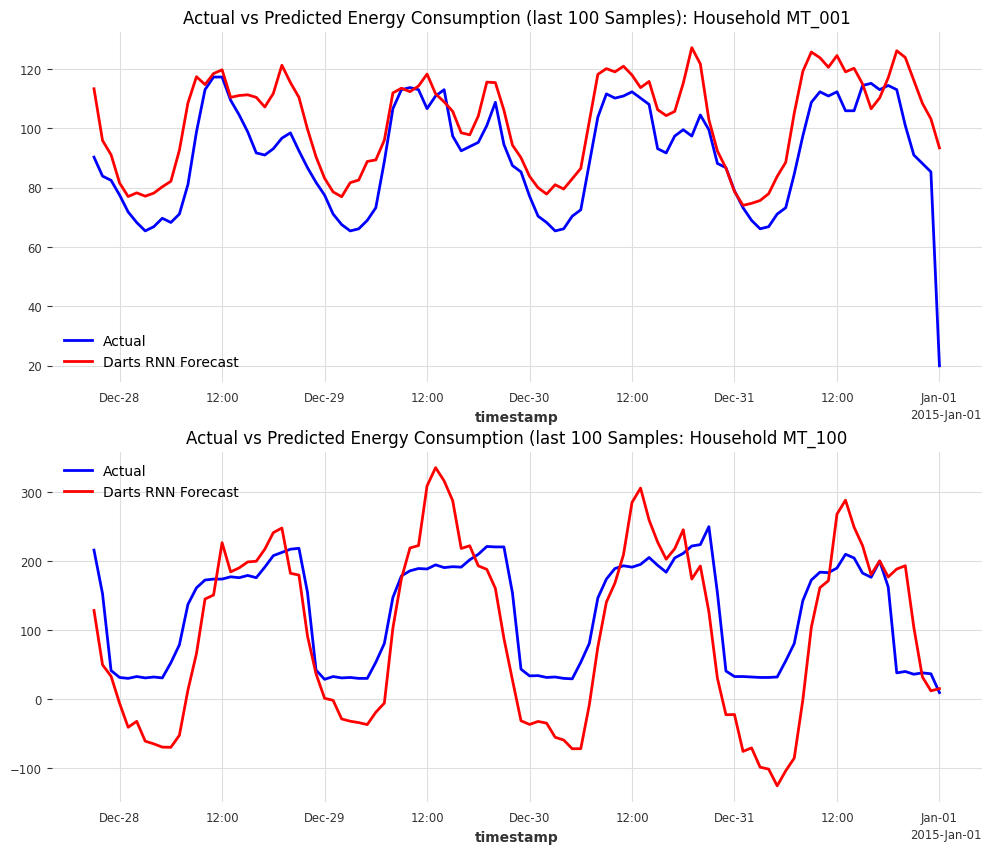

In [ ]:
# Calculate MAE
print("Darts RNN MAE:", mae(test_unscaled, pred_tcn_unscaled))

# Plotting some predictions vs actuals
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot actual values on first subplot
test_unscaled["MT_002"][-100:].plot(label="Actual", color='blue', ax=ax1)
pred_tcn_unscaled["MT_002"][-100:].plot(label="Darts RNN Forecast", color='red', title= "Actual vs Predicted Energy Consumption (last 100 Samples): Household MT_001", ax=ax1)

# Plot predictions on second subplot
test_unscaled["MT_100"][-100:].plot(label="Actual", color='blue', ax=ax2)
pred_tcn_unscaled["MT_100"][-100:].plot(label="Darts RNN Forecast", color='red', title= "Actual vs Predicted Energy Consumption (last 100 Samples: Household MT_100", ax=ax2)

## ✅ Summary

## What You've Accomplished:

- Automated Hyperparameter Optimization: Used Optuna to systematically find optimal model configurations

- TCN Model Tuning: Optimized Temporal Convolutional Network parameters for time series forecasting

- Future Covariates Integration: Enhanced model performance with calendar-based features

- Performance Comparison: Evaluated improvements from systematic tuning vs. manual parameter selection
